In [38]:
# Ensure working directory to project code folder
import os

os.chdir("/ceph/behrens/peter_doohan/goalNav_mFC/experiment/code")
print("Current Working Directory: ", os.getcwd())

from importlib import reload

Current Working Directory:  /ceph/behrens/peter_doohan/goalNav_mFC/experiment/code


In [39]:
# configure matplotlib settings

from matplotlib import pyplot as plt

plt.rcParams.update(
    {
        "font.size": 12,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 8,
        "figure.titlesize": 18,
        "pdf.fonttype": 42,
    }
)
from matplotlib.gridspec import GridSpec

### Plots for main text figure

In [40]:
from GridMaze.analysis.core import get_clusters as gc
from GridMaze.analysis.cluster_tuning import events
from GridMaze.maze import plotting as mp
from GridMaze.maze import representations as mr

In [ ]:
reload(gc)
reload(events)
reload(mp)


def plot_single_unit_figs(cluster_unique_ID, save_label=False):
    """
    Plots the average and goal-stratified trial aligned tuning curves for a given cluster,
    with maze color key (returns separate figs that can be saved separately) and assembled
    into full figure.
    """
    Cluster = gc.get_cluster(cluster_unique_ID)
    f1, ax1 = plt.subplots(1, 1, figsize=(1.5, 0.5), clear=True)
    Cluster.plot_tuning(feature="trial_events", feature_kwargs={"goal_stratified": False, "color": "black"}, ax=ax1)
    ax1.set_xticklabels([])
    ax1.set_ylabel("Hz")

    f2, ax2 = plt.subplots(1, 1, figsize=(6, 2), clear=True)
    Cluster.plot_tuning(feature="trial_events", feature_kwargs={"goal_stratified": True}, ax=ax2)

    goals = Cluster.goals
    simple_maze = mr.get_simple_maze(Cluster.maze_name)
    f3, ax3 = plt.subplots(1, 1, figsize=(1.5, 1.5), clear=True)
    mp.plot_maze_legend(simple_maze, goals, ax=ax3)

    if save_label:
        f1.savefig(f"../results/goal_coding/example_clusters/{save_label}_inset.pdf")
        f2.savefig(f"../results/goal_coding/example_clusters/{save_label}_tuning.pdf")
        f3.savefig(f"../results/goal_coding/example_clusters/{save_label}_legend.pdf")
    else:
        return f1, f2, f3

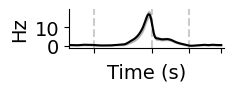

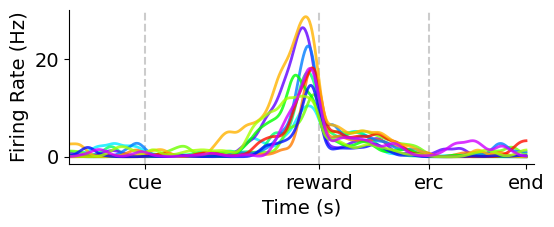

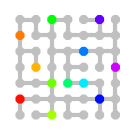

In [48]:
plot_single_unit_figs("m2.2022-07-04.maze_cluster65", save_label="cluster_1")

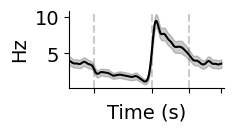

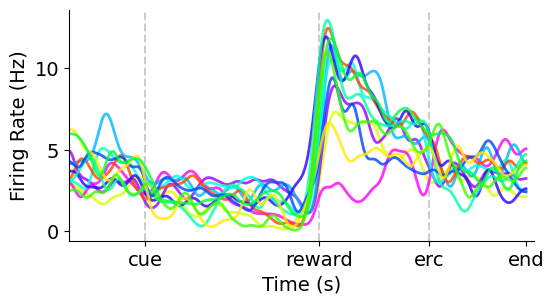

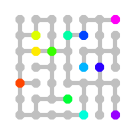

In [43]:
plot_single_unit_figs("m3.2022-07-17.maze_cluster45", save_label="cluster_2")

## Plots for extended data figure 

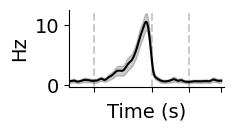

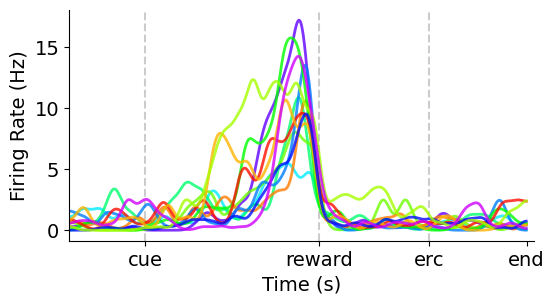

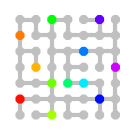

In [44]:
plot_single_unit_figs("m2.2022-07-04.maze_cluster114", save_label="cluster_3")

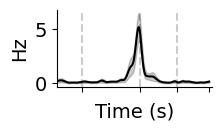

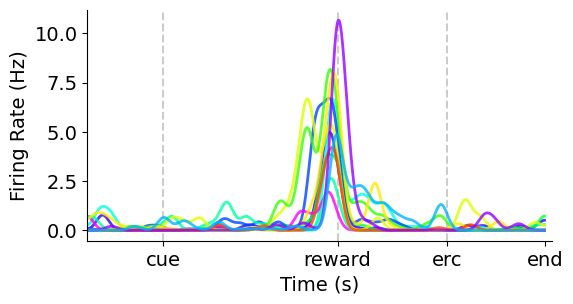

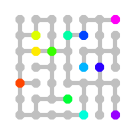

In [45]:
plot_single_unit_figs("m2.2022-07-17.maze_cluster50", save_label="cluster_4")

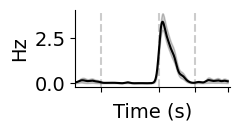

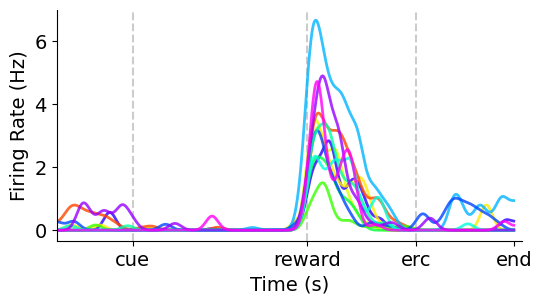

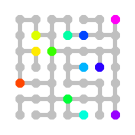

In [46]:
plot_single_unit_figs("m6.2022-07-05.maze_cluster134", save_label="cluster_5")